# Module 3: Financial Markets — Investment Strategy
## Aurora Finance | ML-Driven Decision Support

**Objective:** Build an ML-driven investment strategy for Aurora's equity portfolio by:
1. Exploring and understanding all 6 Indian stocks individually
2. Engineering technical and macroeconomic features
3. Predicting next-day returns using multiple ML models
4. Optimising portfolio weights via Markowitz mean-variance framework
5. Backtesting the ML-driven strategy against an equal-weight benchmark

**Dataset:** `Market Data Revised.xlsx` — 8 sheets
- **Comp 1–6:** 6 Indian stocks × 5,250 daily rows (2005-01-03 to 2026-02-27)
  - Asian Paints, Cipla, HDFC Bank, ITC, TCS, UltraTech Cement
- **Macroeconomic_QRT:** Quarterly GDP growth + Inflation (2005–2025)
- **Macroeconomic_Annual:** Annual GDP growth + Inflation (2005–2024)

> **Note:** The `Return` column in the raw data is the intraday return (close−open)/open.
> For portfolio construction and ML targets, we compute close-to-close daily returns.

In [1]:
import subprocess
pkgs = ["xgboost", "shap", "seaborn", "scikit-learn", "matplotlib",
        "pandas", "numpy", "openpyxl", "scipy"]
subprocess.run(["pip", "install"] + pkgs + ["-q"], check=True)
print("Dependencies ready.")

Dependencies ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor
from scipy.optimize import minimize
from scipy.stats import spearmanr
import shap

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
RANDOM_STATE  = 42
RISK_FREE_RATE = 0.065   # 6.5% India 10yr Gsec rate (annualised)

_nb_dir = os.path.dirname(os.path.abspath("module3_financial_markets.ipynb"))
DATA_FILE = os.path.join(_nb_dir, "Market Data Revised.xlsx")
print("All libraries imported.")

All libraries imported.


---
## 1. Data Loading — All Sheets

In [3]:
xl = pd.read_excel(DATA_FILE, sheet_name=None)
print("Sheets loaded:", list(xl.keys()))

# Clean ticker mapping
TICKER_MAP = {
    "ASIAN PAINTS LTD.":                "ASIANPAINT",
    "CIPLA LTD.":                       "CIPLA",
    "H D F C BANK LTD.":               "HDFCBANK",
    "I T C LTD.":                       "ITC",
    "TATA CONSULTANCY SERVICES LTD.":   "TCS",
    "ULTRATECH CEMENT LTD.":            "ULTRACEMCO",
}

stock_sheets  = [s for s in xl if s.startswith("Comp")]
macro_qrt_raw = xl["Macroeconomic_QRT"]
macro_ann_raw = xl["Macroeconomic_Annual"]

# Load and tag each stock sheet
stock_dfs = {}
for sheet in stock_sheets:
    df = xl[sheet].copy()
    df["date"] = pd.to_datetime(df["date"])
    name = df["company_name"].iloc[0]
    ticker = TICKER_MAP.get(name, name.split()[0])
    df["ticker"] = ticker
    stock_dfs[ticker] = df.sort_values("date").reset_index(drop=True)

print(f"\nStocks loaded: {list(stock_dfs.keys())}")
for t, d in stock_dfs.items():
    print(f"  {t:<14}: {d.shape} | {d['date'].min().date()} to {d['date'].max().date()}")

Sheets loaded: ['Comp 1', 'Comp 2', 'Comp 3', 'Comp 4', 'Comp 5', 'Comp 6', 'Macroeconomic_QRT', 'Macroeconomic_Annual']

Stocks loaded: ['ASIANPAINT', 'CIPLA', 'HDFCBANK', 'ITC', 'TCS', 'ULTRACEMCO']
  ASIANPAINT    : (5250, 10) | 2005-01-03 to 2026-02-27
  CIPLA         : (5250, 10) | 2005-01-03 to 2026-02-27
  HDFCBANK      : (5250, 10) | 2005-01-03 to 2026-02-27
  ITC           : (5250, 10) | 2005-01-03 to 2026-02-27
  TCS           : (5250, 10) | 2005-01-03 to 2026-02-27
  ULTRACEMCO    : (5250, 10) | 2005-01-03 to 2026-02-27


In [4]:
# Clean macro quarterly data
macro_qrt = macro_qrt_raw[["Date","GDP Growth Rate","Inflation Rate (%)"]].copy()
macro_qrt.columns = ["date","gdp_growth","inflation"]
macro_qrt["date"] = pd.to_datetime(macro_qrt["date"])
macro_qrt = macro_qrt.sort_values("date").reset_index(drop=True)
# Forward-fill missing inflation (last 8 quarters)
macro_qrt["inflation"] = macro_qrt["inflation"].ffill()

# Clean macro annual data
macro_ann = macro_ann_raw[["Year","GDP growth (annual %)","Inflation, consumer prices (annual %)"]].copy()
macro_ann.columns = ["year","gdp_annual","inflation_annual"]

print("Macro quarterly (last 5 rows):")
display(macro_qrt.tail())
print(f"\nMacro annual (last 5 rows):")
display(macro_ann.tail())

Macro quarterly (last 5 rows):


,date,gdp_growth,inflation
79,2024-10-01,12.751220,-0.024015
80,2025-01-01,3.813806,-0.024015
81,2025-04-01,-7.502959,-0.024015
82,2025-07-01,0.129783,-0.024015
83,2025-10-01,12.136078,-0.024015



Macro annual (last 5 rows):


,year,gdp_annual,inflation_annual
15,2020,-5.777725,6.623437
16,2021,9.689592,5.131407
17,2022,7.609365,6.699034
18,2023,9.190755,5.649143
19,2024,6.494766,4.953036


---
## 2. Individual Company EDA

Full price history, return distribution, and volume for each of the 6 stocks.

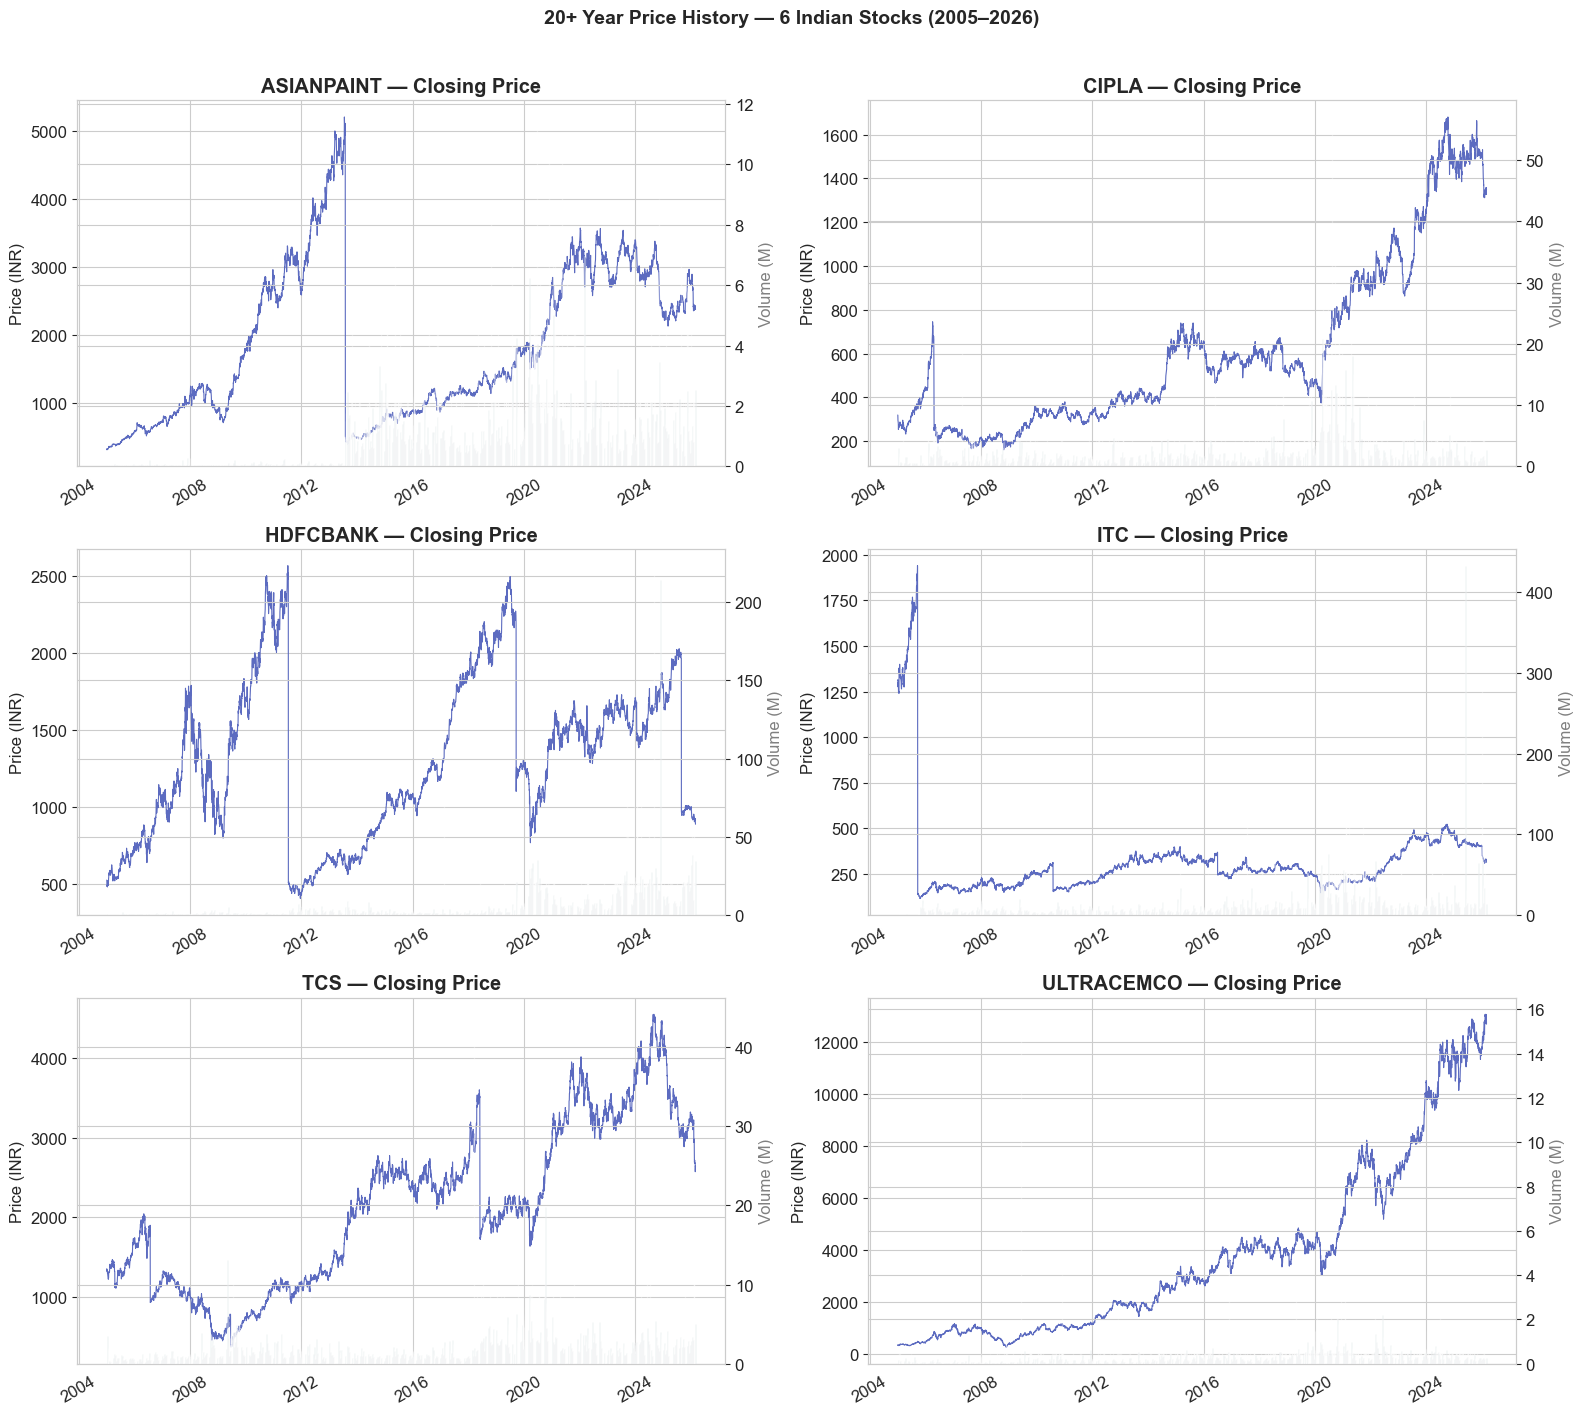

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (ticker, df) in enumerate(stock_dfs.items()):
    ax = axes[i]
    ax.plot(df["date"], df["closing"], color="#5C6BC0", lw=0.8)
    ax.set_title(f"{ticker} — Closing Price", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Price (INR)")
    ax.tick_params(axis="x", rotation=30)
    ax2 = ax.twinx()
    ax2.bar(df["date"], df["trade Volume"]/1e6, color="#B0BEC5", alpha=0.3, width=1)
    ax2.set_ylabel("Volume (M)", color="gray")

plt.suptitle("20+ Year Price History — 6 Indian Stocks (2005–2026)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "stock_price_history.png"), dpi=150, bbox_inches="tight")
plt.show()

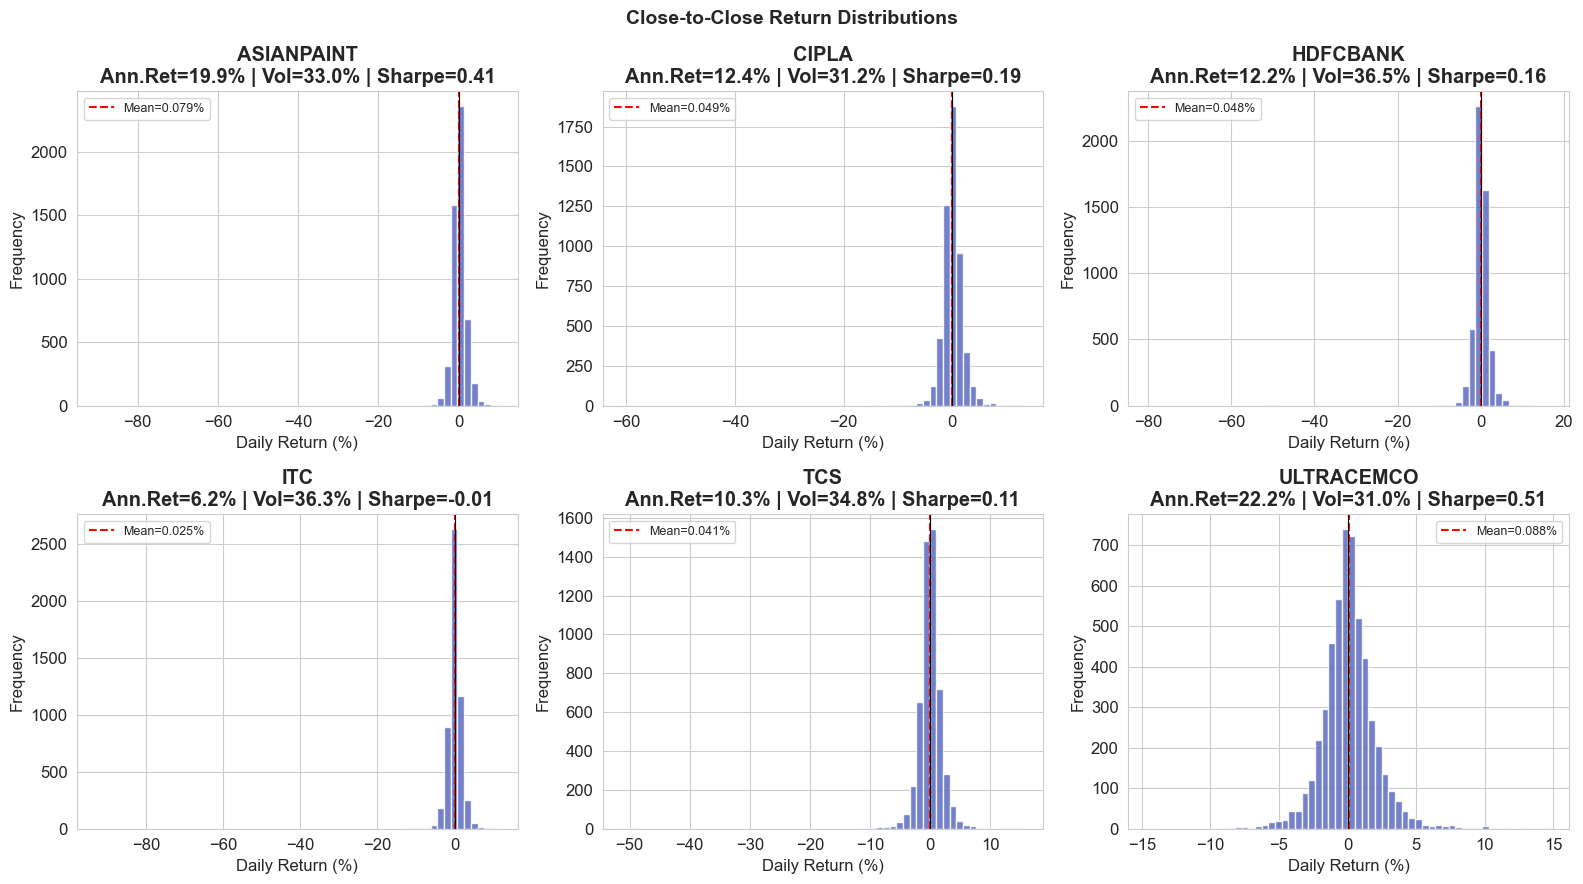

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (ticker, df) in enumerate(stock_dfs.items()):
    # Compute close-to-close returns
    cc_ret = df["closing"].pct_change().dropna()
    ann_ret = cc_ret.mean() * 252
    ann_vol = cc_ret.std() * np.sqrt(252)
    sharpe  = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0

    axes[i].hist(cc_ret * 100, bins=60, color="#5C6BC0", edgecolor="white", alpha=0.85)
    axes[i].axvline(cc_ret.mean()*100, color="red",    linestyle="--", lw=1.5, label=f"Mean={cc_ret.mean()*100:.3f}%")
    axes[i].axvline(0,               color="black",  linestyle="-",  lw=0.8)
    axes[i].set_title(f"{ticker}\nAnn.Ret={ann_ret:.1%} | Vol={ann_vol:.1%} | Sharpe={sharpe:.2f}", fontweight="bold")
    axes[i].set_xlabel("Daily Return (%)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

plt.suptitle("Close-to-Close Return Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "return_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

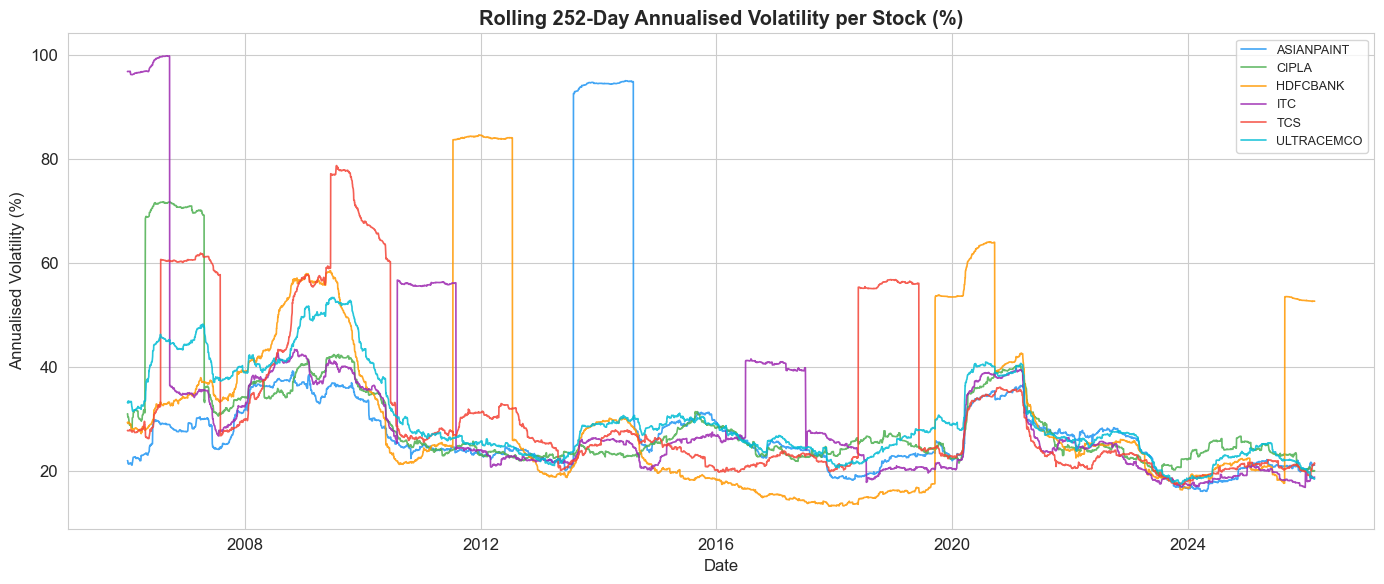

In [7]:
# Rolling 252-day annualised volatility for each stock
fig, ax = plt.subplots(figsize=(14, 6))
colors_roll = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4"]

for (ticker, df), color in zip(stock_dfs.items(), colors_roll):
    cc_ret = df["closing"].pct_change()
    roll_vol = cc_ret.rolling(252).std() * np.sqrt(252) * 100
    ax.plot(df["date"], roll_vol, label=ticker, color=color, lw=1.2, alpha=0.85)

ax.set_title("Rolling 252-Day Annualised Volatility per Stock (%)", fontweight="bold")
ax.set_ylabel("Annualised Volatility (%)"); ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "rolling_volatility.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Cross-Stock Analysis

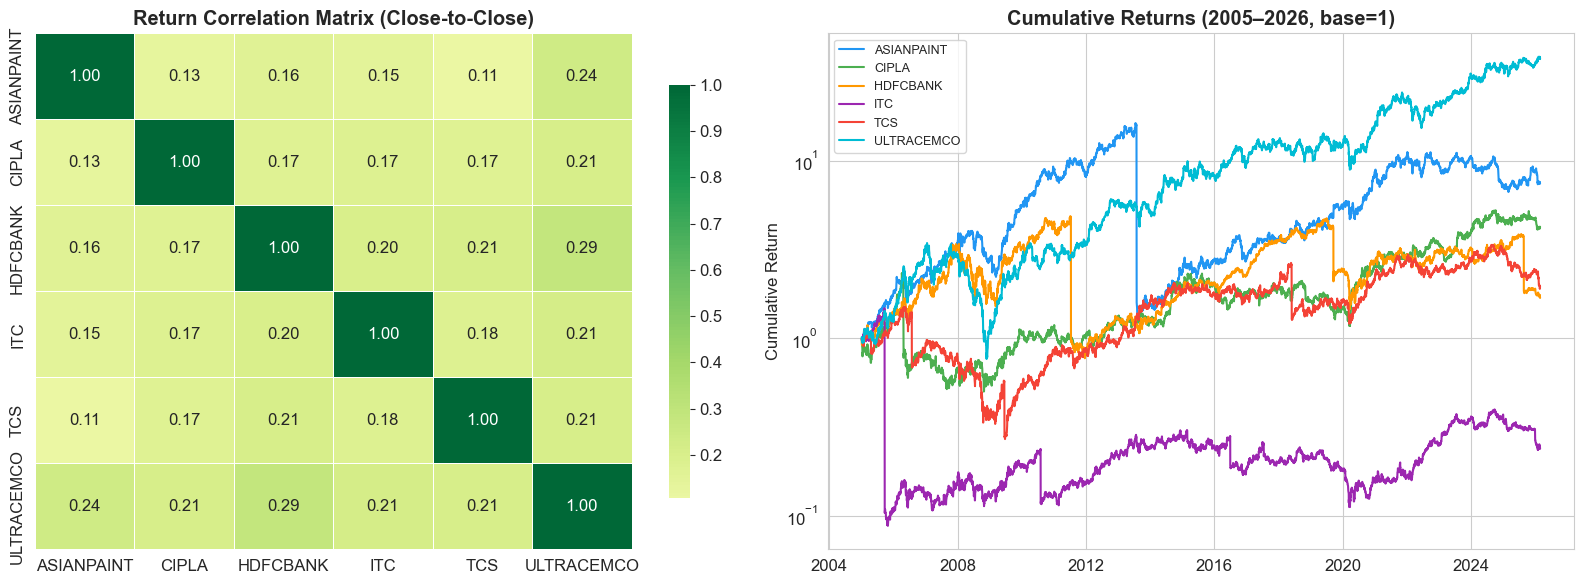

Correlation summary:
            ASIANPAINT  CIPLA  HDFCBANK    ITC    TCS  ULTRACEMCO
ASIANPAINT       1.000  0.131     0.164  0.146  0.108       0.238
CIPLA            0.131  1.000     0.168  0.174  0.171       0.206
HDFCBANK         0.164  0.168     1.000  0.202  0.210       0.287
ITC              0.146  0.174     0.202  1.000  0.180       0.215
TCS              0.108  0.171     0.210  0.180  1.000       0.208
ULTRACEMCO       0.238  0.206     0.287  0.215  0.208       1.000


In [8]:
# Merge all stocks into a single DataFrame (close-to-close returns)
all_close = pd.DataFrame({t: d.set_index("date")["closing"] for t, d in stock_dfs.items()})
all_ret   = all_close.pct_change().dropna()
tickers   = list(stock_dfs.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
corr = all_ret.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=axes[0], linewidths=0.5, cbar_kws={"shrink":0.8})
axes[0].set_title("Return Correlation Matrix (Close-to-Close)", fontweight="bold")

# Cumulative performance
cum_ret = (1 + all_ret).cumprod()
for ticker, color in zip(tickers, ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4"]):
    axes[1].plot(cum_ret.index, cum_ret[ticker], label=ticker, color=color, lw=1.5)
axes[1].set_title("Cumulative Returns (2005–2026, base=1)", fontweight="bold")
axes[1].set_ylabel("Cumulative Return"); axes[1].legend(fontsize=9)
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "cross_stock_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Correlation summary:")
print(corr.round(3).to_string())

In [9]:
# Summary stats table for all 6 stocks
stats_rows = []
for ticker, df in stock_dfs.items():
    cc_ret = df["closing"].pct_change().dropna()
    ann_ret = cc_ret.mean() * 252
    ann_vol = cc_ret.std() * np.sqrt(252)
    sharpe  = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0
    stats_rows.append({
        "Ticker":      ticker,
        "Company":     df["company_name"].iloc[0],
        "First Price": f"{df['closing'].iloc[0]:.0f}",
        "Last Price":  f"{df['closing'].iloc[-1]:.0f}",
        "Total Gain":  f"{(df['closing'].iloc[-1]/df['closing'].iloc[0]-1):.0%}",
        "Ann. Return": f"{ann_ret:.1%}",
        "Ann. Vol":    f"{ann_vol:.1%}",
        "Sharpe":      f"{sharpe:.2f}",
    })
display(pd.DataFrame(stats_rows))

,Ticker,Company,First Price,Last Price,Total Gain,Ann. Return,Ann. Vol,Sharpe
0,ASIANPAINT,ASIAN PAINTS LTD.,319,2376,645%,19.9%,33.0%,0.41
1,CIPLA,CIPLA LTD.,319,1348,323%,12.4%,31.2%,0.19
2,HDFCBANK,H D F C BANK LTD.,525,888,69%,12.2%,36.5%,0.16
3,ITC,I T C LTD.,1313,314,-76%,6.2%,36.3%,-0.01
4,TCS,TATA CONSULTANCY SERVICES LTD.,1353,2637,95%,10.3%,34.8%,0.11
5,ULTRACEMCO,ULTRATECH CEMENT LTD.,338,12677,3649%,22.2%,31.0%,0.51


---
## 4. Data Preparation — Merged Panel Dataset

Stack all 6 stocks into a long-format panel with close-to-close returns and macro data merged by quarter.

In [10]:
# Build long-format panel
panel_dfs = []
for ticker, df in stock_dfs.items():
    p = df[["date","opening","high","low","closing","trade Volume"]].copy()
    p["ticker"]       = ticker
    p["cc_return"]    = p["closing"].pct_change()              # close-to-close return
    p["next_return"]  = p["cc_return"].shift(-1)               # TARGET: next-day return
    panel_dfs.append(p)

panel = pd.concat(panel_dfs).sort_values(["ticker","date"]).reset_index(drop=True)
panel = panel.dropna(subset=["cc_return"])

# Merge quarterly macro: assign each date to its quarter
macro_qrt_sorted = macro_qrt.sort_values("date")
panel["quarter"]  = panel["date"].dt.to_period("Q").dt.to_timestamp()
panel = panel.merge(macro_qrt_sorted.rename(columns={"date":"quarter"}),
                    on="quarter", how="left")
panel["gdp_growth"]  = panel["gdp_growth"].ffill()
panel["inflation"]   = panel["inflation"].ffill()
panel = panel.drop(columns="quarter")

print(f"Panel shape: {panel.shape}")
print(f"Date range : {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"Missing values:\n{panel.isnull().sum()[panel.isnull().sum()>0]}")
display(panel.head())

Panel shape: (31494, 11)
Date range : 2005-01-04 to 2026-02-27
Missing values:
next_return    6
dtype: int64


,date,opening,high,low,closing,trade Volume,ticker,cc_return,next_return,gdp_growth,inflation
0,2005-01-04,322.00,324.90,320.00,324.05,32240,ASIANPAINT,0.015512,-0.006789,3.916985,0.254453
1,2005-01-05,324.05,324.95,320.00,321.85,30500,ASIANPAINT,-0.006789,-0.038527,3.916985,0.254453
2,2005-01-06,327.00,327.00,302.55,309.45,38985,ASIANPAINT,-0.038527,0.034254,3.916985,0.254453
3,2005-01-07,310.00,322.00,309.10,320.05,17621,ASIANPAINT,0.034254,0.005468,3.916985,0.254453
4,2005-01-10,323.00,324.00,317.05,321.80,17363,ASIANPAINT,0.005468,-0.004661,3.916985,0.254453


---
## 5. Feature Engineering

**Set A — Technical features only** (price + volume derived)

**Set B — Technical + Macro features**

| Feature | Window | Business Meaning |
|---|---|---|
| `ret_5d` / `ret_10d` / `ret_21d` | 5,10,21 days | Short/medium momentum |
| `vol_10d` / `vol_21d` | 10,21 days | Rolling volatility |
| `mom_63d` | 63 days | ~3-month momentum signal |
| `ma_ratio_20` / `ma_ratio_50` | 20,50 days | Price vs moving average |
| `rel_volume` | 21 days | Volume relative to 21-day average |
| `log_volume` | — | Log-normalised trading volume |
| `gdp_growth` | quarterly | Macro tailwind/headwind |
| `inflation` | quarterly | Cost-push pressure indicator |
| Ticker dummies | — | Stock identity (pooled model) |

In [11]:
def add_features(df):
    d = df.copy().sort_values("date")

    # Rolling returns (momentum)
    d["ret_5d"]   = d["cc_return"].rolling(5).mean()
    d["ret_10d"]  = d["cc_return"].rolling(10).mean()
    d["ret_21d"]  = d["cc_return"].rolling(21).mean()
    d["mom_63d"]  = d["cc_return"].rolling(63).sum()

    # Rolling volatility
    d["vol_10d"]  = d["cc_return"].rolling(10).std()
    d["vol_21d"]  = d["cc_return"].rolling(21).std()

    # Price vs moving average
    d["ma_20"]       = d["closing"].rolling(20).mean()
    d["ma_50"]       = d["closing"].rolling(50).mean()
    d["ma_ratio_20"] = d["closing"] / d["ma_20"] - 1
    d["ma_ratio_50"] = d["closing"] / d["ma_50"] - 1

    # Volume features
    d["log_volume"]  = np.log1p(d["trade Volume"])
    d["rel_volume"]  = d["trade Volume"] / (d["trade Volume"].rolling(21).mean() + 1)

    # Intraday range
    d["hl_range"] = (d["high"] - d["low"]) / d["closing"]

    return d

_feat_parts = []
for _t in panel["ticker"].unique():
    _feat_parts.append(add_features(panel[panel["ticker"] == _t].copy()))
panel_feat = pd.concat(_feat_parts).sort_values(["date","ticker"]).reset_index(drop=True)

# Ticker one-hot encoding
ticker_dummies = pd.get_dummies(panel_feat["ticker"], prefix="T", drop_first=False)
panel_feat = pd.concat([panel_feat, ticker_dummies], axis=1)
ticker_dummy_cols = [c for c in panel_feat.columns if c.startswith("T_")]

# Feature sets
TECH_FEATURES  = ["ret_5d","ret_10d","ret_21d","mom_63d",
                   "vol_10d","vol_21d","ma_ratio_20","ma_ratio_50",
                   "rel_volume","log_volume","hl_range"] + ticker_dummy_cols

MACRO_FEATURES = TECH_FEATURES + ["gdp_growth","inflation"]

TARGET = "next_return"

# Drop rows with NaN features (first ~63 rows per stock)
panel_clean = panel_feat.dropna(subset=TECH_FEATURES + [TARGET]).copy()
print(f"Panel after feature engineering: {panel_clean.shape}")
print(f"Technical features  : {len(TECH_FEATURES)}")
print(f"Technical + Macro   : {len(MACRO_FEATURES)}")
panel_clean[["date","ticker"] + TECH_FEATURES[:5]].head()

Panel after feature engineering: (31116, 30)
Technical features  : 17
Technical + Macro   : 19


,date,ticker,ret_5d,ret_10d,ret_21d,mom_63d,vol_10d
372,2005-04-05,ASIANPAINT,0.003072,-0.000316,0.004905,0.209978,0.007990
373,2005-04-05,CIPLA,0.006912,-0.005263,-0.001544,-0.187885,0.019535
374,2005-04-05,HDFCBANK,0.001231,-0.003305,-0.003708,0.041047,0.020600
375,2005-04-05,ITC,0.011736,0.004303,-0.000647,0.040144,0.021530
376,2005-04-05,TCS,0.007955,-0.002012,0.001214,0.057575,0.017485


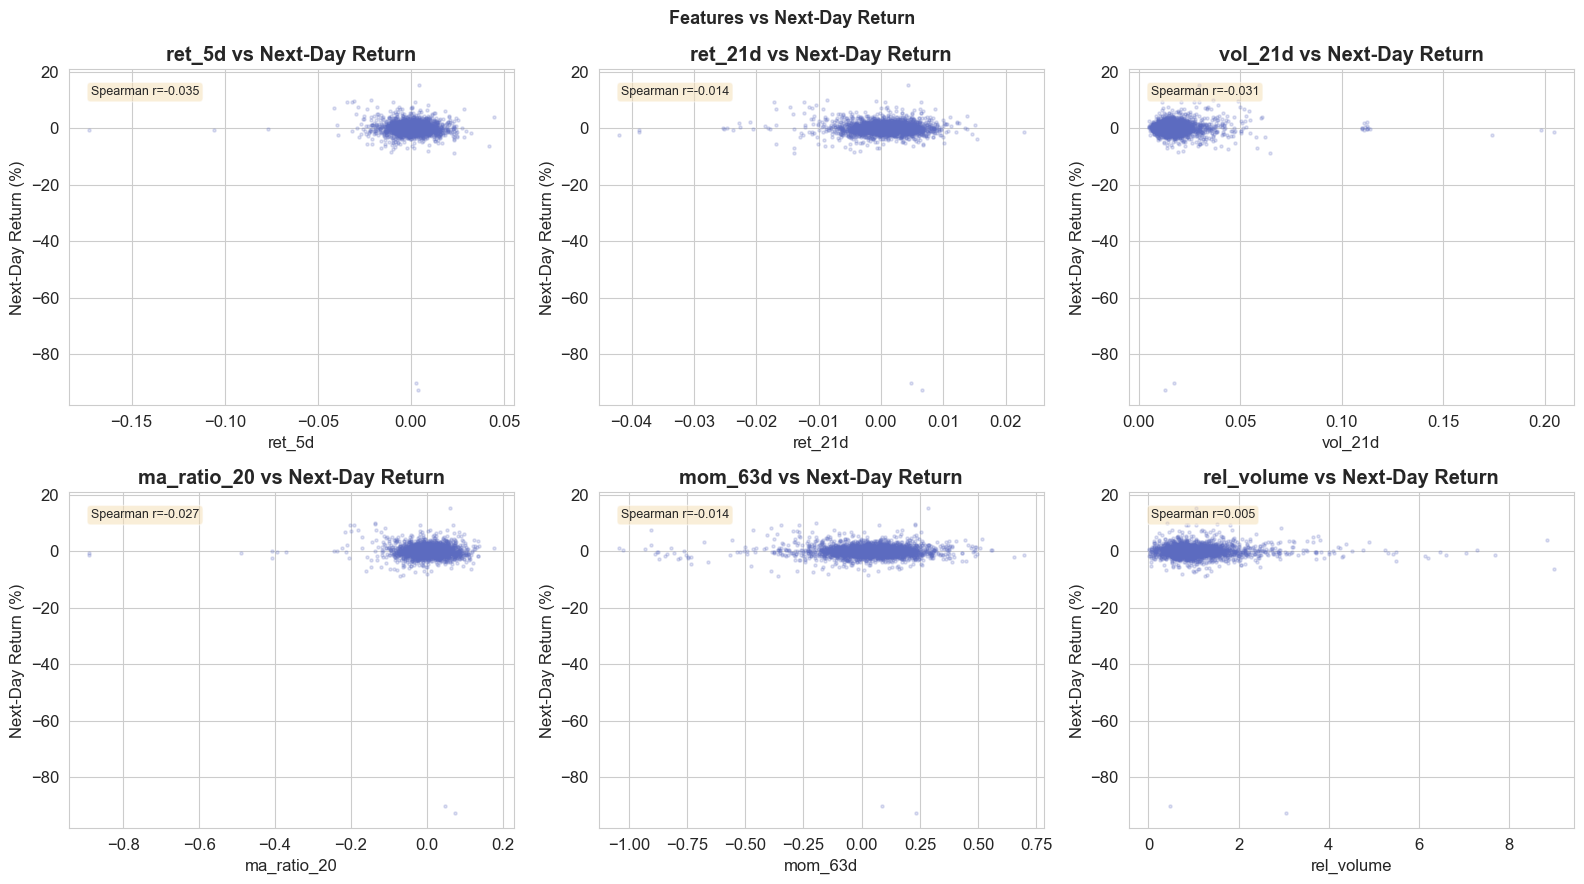

In [12]:
# Visualise key features vs next return
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

feat_plot = ["ret_5d","ret_21d","vol_21d","ma_ratio_20","mom_63d","rel_volume"]
for i, feat in enumerate(feat_plot):
    sample = panel_clean.sample(min(3000, len(panel_clean)), random_state=42)
    axes[i].scatter(sample[feat], sample[TARGET]*100, alpha=0.2, s=5, color="#5C6BC0")
    axes[i].set_xlabel(feat); axes[i].set_ylabel("Next-Day Return (%)")
    axes[i].set_title(f"{feat} vs Next-Day Return", fontweight="bold")
    # Add correlation annotation
    corr_val, _ = spearmanr(sample[feat], sample[TARGET])
    axes[i].text(0.05, 0.95, f"Spearman r={corr_val:.3f}",
                 transform=axes[i].transAxes, fontsize=9, va="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Features vs Next-Day Return", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "feature_vs_return.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Return Prediction — ML Models

**Goal:** Predict next-day close-to-close return using technical + macro features.

**Approach:** Time-series cross-validation (5 folds, no future leakage) on **pooled panel** (all 6 stocks together).

**Models:** Linear Regression, Ridge, Random Forest, XGBoost, Gradient Boosting

**Evaluation metrics:**
- **RMSE / MAE** — absolute prediction error
- **R²** — variance explained (typically very low for stock returns — expected)
- **Directional Accuracy** — % of times the predicted sign matches actual (>50% = useful signal)
- **IC (Information Coefficient)** — Spearman rank correlation between predicted and actual returns

In [13]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def information_coefficient(y_true, y_pred):
    ic, _ = spearmanr(y_pred, y_true)
    return ic if not np.isnan(ic) else 0.0

def eval_regression_ts(models, X, y, dates, n_splits=5, label=""):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []
    for name, model in models.items():
        rmses, maes, r2s, dirs, ics = [], [], [], [], []
        for tr, te in tscv.split(X):
            m = clone(model)
            m.fit(X[tr], y[tr])
            pred = m.predict(X[te])
            rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
            maes.append(mean_absolute_error(y[te], pred))
            r2s.append(r2_score(y[te], pred))
            dirs.append(directional_accuracy(y[te], pred))
            ics.append(information_coefficient(y[te], pred))
        results.append({
            "Model":      name,
            "RMSE":       f"{np.mean(rmses):.5f} +/- {np.std(rmses):.5f}",
            "MAE":        f"{np.mean(maes):.5f} +/- {np.std(maes):.5f}",
            "R2":         f"{np.mean(r2s):.4f} +/- {np.std(r2s):.4f}",
            "Dir.Acc.":   f"{np.mean(dirs):.3f} +/- {np.std(dirs):.3f}",
            "IC":         f"{np.mean(ics):.4f} +/- {np.std(ics):.4f}",
            "_ic":        np.mean(ics),
            "_dir":       np.mean(dirs),
        })
    df_r = pd.DataFrame(results).sort_values("_ic", ascending=False)
    print(f"\nReturn Prediction — {label}")
    display(df_r.drop(columns=["_ic","_dir"]).reset_index(drop=True))
    return df_r

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, max_depth=5,
                                                n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost":           XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=RANDOM_STATE, verbosity=0),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                                    max_depth=3, random_state=RANDOM_STATE),
}

panel_sorted = panel_clean.sort_values(["date","ticker"])
X_A = panel_sorted[TECH_FEATURES].values
X_B = panel_sorted[MACRO_FEATURES].values
y   = panel_sorted[TARGET].values
dates_sorted = panel_sorted["date"].values

res_A = eval_regression_ts(reg_models, X_A, y, dates_sorted, n_splits=5, label="Set A (Technical Only)")
res_B = eval_regression_ts(reg_models, X_B, y, dates_sorted, n_splits=5, label="Set B (Technical + Macro)")


Return Prediction — Set A (Technical Only)


,Model,RMSE,MAE,R2,Dir.Acc.,IC
0,Ridge,0.01939 +/- 0.00385,0.01197 +/- 0.00201,-0.0027 +/- 0.0012,0.506 +/- 0.007,0.0181 +/- 0.0145
1,Linear Regression,0.01940 +/- 0.00385,0.01198 +/- 0.00201,-0.0037 +/- 0.0011,0.507 +/- 0.006,0.0178 +/- 0.0118
2,Random Forest,0.01960 +/- 0.00414,0.01206 +/- 0.00215,-0.0204 +/- 0.0280,0.508 +/- 0.005,0.0057 +/- 0.0092
3,GradientBoosting,0.01954 +/- 0.00398,0.01205 +/- 0.00210,-0.0163 +/- 0.0118,0.506 +/- 0.007,0.0055 +/- 0.0161
4,XGBoost,0.01980 +/- 0.00419,0.01227 +/- 0.00228,-0.0417 +/- 0.0278,0.502 +/- 0.002,-0.0003 +/- 0.0139



Return Prediction — Set B (Technical + Macro)


,Model,RMSE,MAE,R2,Dir.Acc.,IC
0,Linear Regression,0.01940 +/- 0.00387,0.01198 +/- 0.00203,-0.0043 +/- 0.0022,0.505 +/- 0.009,0.0175 +/- 0.0131
1,Ridge,0.01939 +/- 0.00386,0.01197 +/- 0.00202,-0.0033 +/- 0.0020,0.504 +/- 0.006,0.0171 +/- 0.0157
2,GradientBoosting,0.01955 +/- 0.00397,0.01207 +/- 0.00210,-0.0177 +/- 0.0106,0.507 +/- 0.005,0.0090 +/- 0.0129
3,XGBoost,0.01989 +/- 0.00420,0.01235 +/- 0.00225,-0.0515 +/- 0.0280,0.506 +/- 0.008,0.0052 +/- 0.0170
4,Random Forest,0.01961 +/- 0.00416,0.01208 +/- 0.00217,-0.0215 +/- 0.0290,0.508 +/- 0.006,0.0047 +/- 0.0088


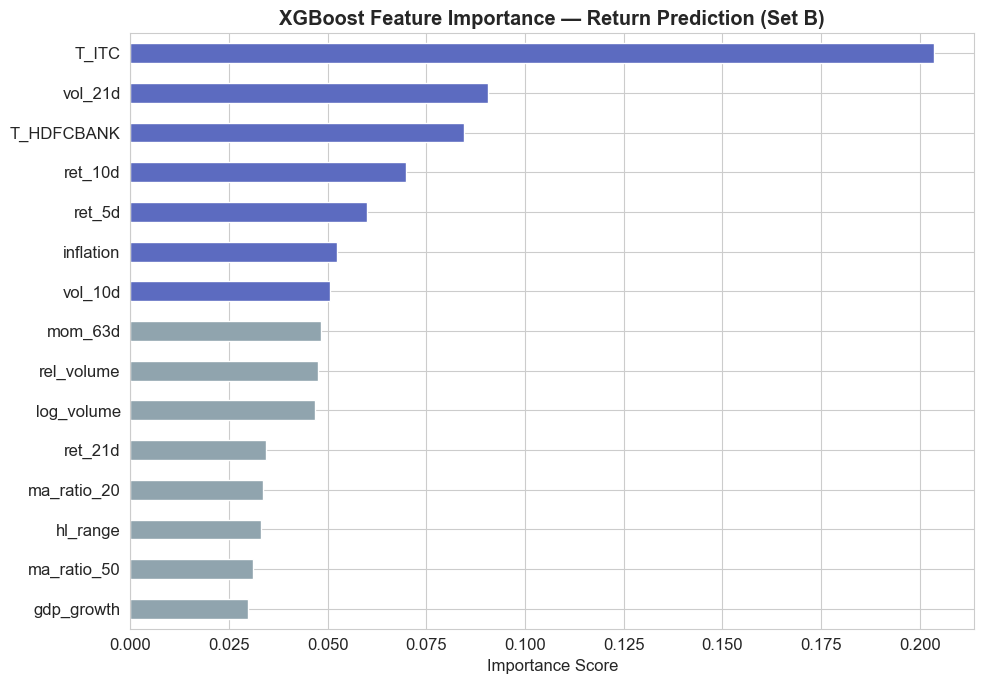

In [14]:
# Train best model (XGBoost, Set B) on full data
best_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=RANDOM_STATE, verbosity=0)
best_model.fit(panel_sorted[MACRO_FEATURES], y)
panel_sorted = panel_sorted.copy()
panel_sorted["pred_return"] = best_model.predict(panel_sorted[MACRO_FEATURES])

# Feature importance
feat_imp = pd.Series(best_model.feature_importances_, index=MACRO_FEATURES).sort_values(ascending=True).tail(15)
plt.figure(figsize=(10, 7))
colors_fi = ["#5C6BC0" if v > feat_imp.median() else "#90A4AE" for v in feat_imp.values]
feat_imp.plot(kind="barh", color=colors_fi)
plt.title("XGBoost Feature Importance — Return Prediction (Set B)", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "feat_importance_returns.png"), dpi=150, bbox_inches="tight")
plt.show()

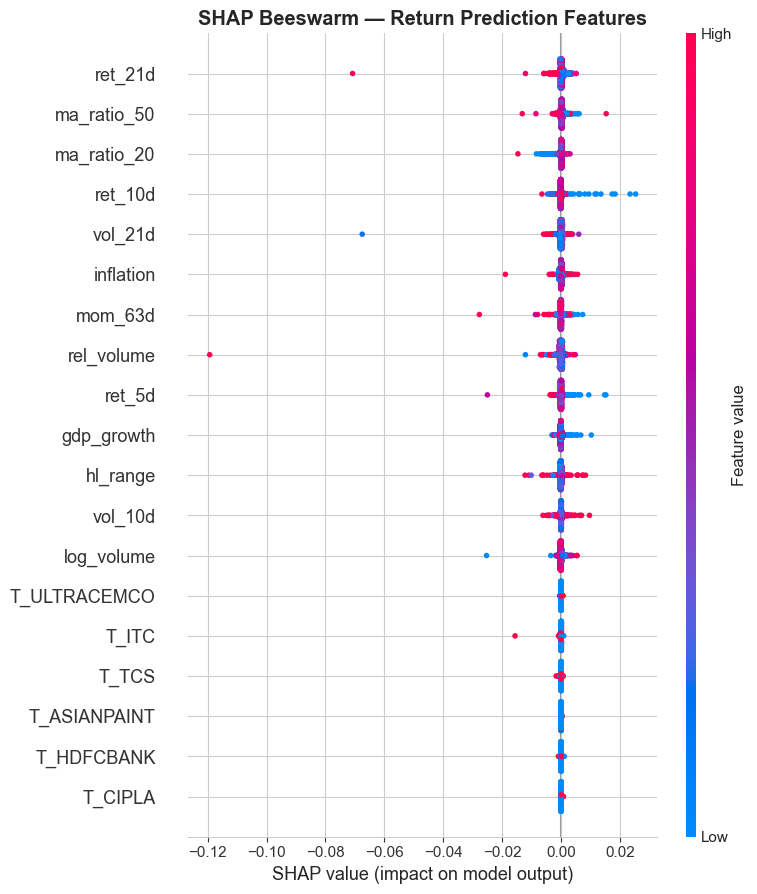

In [15]:
# SHAP analysis on a 2000-row sample (for performance)
sample_idx = np.random.RandomState(42).choice(len(panel_sorted), size=min(2000, len(panel_sorted)), replace=False)
X_sample = panel_sorted[MACRO_FEATURES].iloc[sample_idx]

explainer_ret  = shap.TreeExplainer(best_model)
shap_ret       = explainer_ret.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_ret, X_sample, feature_names=MACRO_FEATURES, show=False)
plt.title("SHAP Beeswarm — Return Prediction Features", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "shap_returns.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Stock Ranking by Predicted Return

Rank all 6 stocks by their average predicted return over the most recent 21 trading days.

=== Stock Ranking by Predicted Annualised Return (last 21 days) ===


,ticker,Ann_Pred_Return,Ann_Volatility,Pred_Sharpe
1,ITC,32.4%,28.1%,0.92
2,ULTRACEMCO,21.6%,21.6%,0.70
3,CIPLA,14.0%,19.4%,0.39
4,ASIANPAINT,14.0%,29.3%,0.25
5,HDFCBANK,4.9%,15.1%,-0.11
6,TCS,-6.3%,32.0%,-0.40


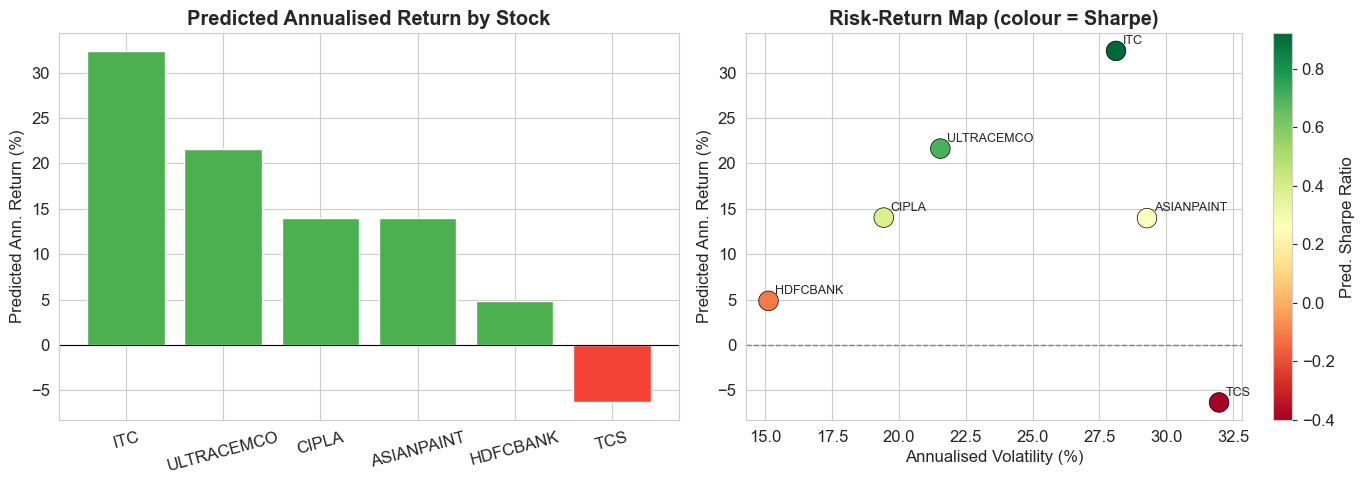

In [16]:
# Use last 21 rows per stock for ranking (most recent predictions)
latest_date = panel_sorted["date"].max()
recent = panel_sorted.groupby("ticker").tail(21)

rank_df = recent.groupby("ticker").agg(
    Pred_Return_Mean=("pred_return", "mean"),
    Actual_Return_Mean=("cc_return",  "mean"),
    Vol_21d=("vol_21d", "mean"),
).reset_index()

rank_df["Ann_Pred_Return"] = rank_df["Pred_Return_Mean"] * 252
rank_df["Ann_Volatility"]  = rank_df["Vol_21d"] * np.sqrt(252)
rank_df["Pred_Sharpe"]     = (rank_df["Ann_Pred_Return"] - RISK_FREE_RATE) / rank_df["Ann_Volatility"]
rank_df = rank_df.sort_values("Ann_Pred_Return", ascending=False).reset_index(drop=True)
rank_df.index += 1

print("=== Stock Ranking by Predicted Annualised Return (last 21 days) ===")
display_df = rank_df.copy()
display_df["Ann_Pred_Return"] = display_df["Ann_Pred_Return"].map("{:.1%}".format)
display_df["Ann_Volatility"]  = display_df["Ann_Volatility"].map("{:.1%}".format)
display_df["Pred_Sharpe"]     = display_df["Pred_Sharpe"].map("{:.2f}".format)
display(display_df[["ticker","Ann_Pred_Return","Ann_Volatility","Pred_Sharpe"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_rank = ["#4CAF50" if v > 0 else "#F44336" for v in rank_df["Ann_Pred_Return"]]
axes[0].bar(rank_df["ticker"], rank_df["Ann_Pred_Return"]*100, color=colors_rank, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Predicted Annualised Return by Stock", fontweight="bold")
axes[0].set_ylabel("Predicted Ann. Return (%)")
axes[0].tick_params(axis="x", rotation=15)

# Risk-return scatter
sc = axes[1].scatter(rank_df["Ann_Volatility"]*100, rank_df["Ann_Pred_Return"]*100,
                     s=200, c=rank_df["Pred_Sharpe"], cmap="RdYlGn",
                     edgecolors="black", linewidth=0.5, zorder=5)
for _, row in rank_df.iterrows():
    axes[1].annotate(row["ticker"],
                     (row["Ann_Volatility"]*100, row["Ann_Pred_Return"]*100),
                     textcoords="offset points", xytext=(5,5), fontsize=9)
axes[1].axhline(0, color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("Annualised Volatility (%)"); axes[1].set_ylabel("Predicted Ann. Return (%)")
axes[1].set_title("Risk-Return Map (colour = Sharpe)", fontweight="bold")
plt.colorbar(sc, ax=axes[1], label="Pred. Sharpe Ratio")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "stock_ranking.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Portfolio Optimisation — Markowitz Mean-Variance

**Inputs:**
- Expected returns: from ML predictions (last 21-day mean, annualised)
- Covariance matrix: from last 252 days of historical close-to-close returns

**Portfolios solved:**
1. **Minimum Variance Portfolio** — minimise total volatility
2. **Maximum Sharpe Portfolio** — maximise risk-adjusted return
3. **Equal Weight Benchmark** — 1/6 in each stock

In [17]:
def markowitz_optimize(mu, cov, risk_free=RISK_FREE_RATE, mode="max_sharpe"):
    n = len(mu)
    init_w = np.ones(n) / n
    bounds = [(0.0, 1.0)] * n
    constraints = [{"type":"eq", "fun": lambda w: np.sum(w) - 1}]

    if mode == "min_var":
        def objective(w): return w @ cov @ w
    else:  # max_sharpe
        def objective(w):
            port_ret = w @ mu
            port_vol = np.sqrt(w @ cov @ w)
            return -(port_ret - risk_free) / (port_vol + 1e-10)

    res = minimize(objective, init_w, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol":1e-9, "maxiter":1000})
    return res.x if res.success else init_w

# Compute expected returns and covariance from last 252 trading days
last_252 = all_ret.tail(252)
mu_hist  = last_252.mean() * 252              # annualised historical mean
mu_ml    = rank_df.set_index("ticker")["Ann_Pred_Return"].reindex(tickers).values
cov_mat  = last_252.cov().values * 252       # annualised covariance

w_min_var   = markowitz_optimize(mu_ml, cov_mat, mode="min_var")
w_max_sharpe = markowitz_optimize(mu_ml, cov_mat, mode="max_sharpe")
w_equal     = np.ones(len(tickers)) / len(tickers)

def port_stats(w, mu, cov, rf=RISK_FREE_RATE):
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    sharpe = (ret - rf) / (vol + 1e-10)
    return ret, vol, sharpe

def show_portfolio(name, w, mu, cov):
    ret, vol, sharpe = port_stats(w, mu, cov)
    print(f"\n{name}:")
    print(f"  Expected Return : {ret:.2%}")
    print(f"  Volatility      : {vol:.2%}")
    print(f"  Sharpe Ratio    : {sharpe:.2f}")
    for t, wi in zip(tickers, w):
        print(f"  {t:<14}: {wi:.1%}")
    return ret, vol, sharpe

stats_mv  = show_portfolio("Min-Variance Portfolio",   w_min_var,    mu_ml, cov_mat)
stats_ms  = show_portfolio("Max-Sharpe Portfolio",     w_max_sharpe, mu_ml, cov_mat)
stats_eq  = show_portfolio("Equal Weight Benchmark",   w_equal,      mu_ml, cov_mat)


Min-Variance Portfolio:
  Expected Return : 16.34%
  Volatility      : 11.93%
  Sharpe Ratio    : 0.82
  ASIANPAINT    : 12.2%
  CIPLA         : 16.5%
  HDFCBANK      : 3.0%
  ITC           : 26.9%
  TCS           : 19.7%
  ULTRACEMCO    : 21.8%

Max-Sharpe Portfolio:
  Expected Return : 29.04%
  Volatility      : 15.26%
  Sharpe Ratio    : 1.48
  ASIANPAINT    : 0.0%
  CIPLA         : 0.0%
  HDFCBANK      : 0.0%
  ITC           : 68.9%
  TCS           : 0.0%
  ULTRACEMCO    : 31.1%

Equal Weight Benchmark:
  Expected Return : 13.42%
  Volatility      : 14.12%
  Sharpe Ratio    : 0.49
  ASIANPAINT    : 16.7%
  CIPLA         : 16.7%
  HDFCBANK      : 16.7%
  ITC           : 16.7%
  TCS           : 16.7%
  ULTRACEMCO    : 16.7%


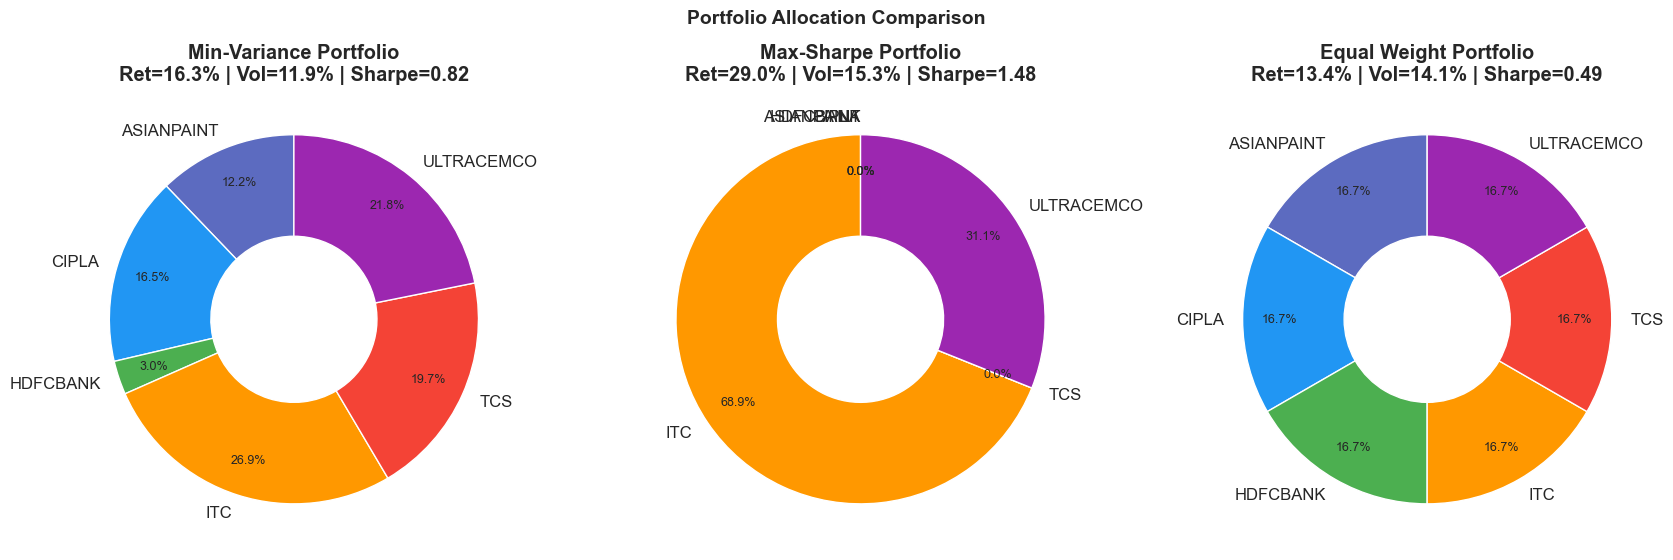

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

colors_port = ["#5C6BC0","#2196F3","#4CAF50","#FF9800","#F44336","#9C27B0"]

for ax, (name, weights) in zip(axes, [
        ("Min-Variance", w_min_var),
        ("Max-Sharpe",   w_max_sharpe),
        ("Equal Weight", w_equal)]):
    wedges, texts, autotexts = ax.pie(
        weights, labels=tickers, autopct="%1.1f%%",
        colors=colors_port, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white"),
        pctdistance=0.8)
    for at in autotexts: at.set_fontsize(9)
    ret, vol, sharpe = port_stats(weights, mu_ml, cov_mat)
    ax.set_title(f"{name} Portfolio\nRet={ret:.1%} | Vol={vol:.1%} | Sharpe={sharpe:.2f}", fontweight="bold")

plt.suptitle("Portfolio Allocation Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "portfolio_allocation.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Backtesting — Rolling Window (2024–2026)

**Method:** Walk-forward rolling window
- **Training window:** 500 trading days (approx. 2 years history before test period)
- **Test window:** 21 trading days (1 month)
- At each step: retrain XGBoost → predict returns → optimise Markowitz weights → hold for 21 days
- Compare: ML Max-Sharpe vs Equal-Weight benchmark

In [19]:
# Prepare wide-format returns and features for backtesting
backtest_start = pd.Timestamp("2024-01-01")
TRAIN_WINDOW   = 500
TEST_WINDOW    = 21

# Use panel_sorted (sorted by date then ticker)
dates_unique = sorted(panel_sorted["date"].unique())
bt_dates     = [d for d in dates_unique if pd.Timestamp(d) >= backtest_start]

print(f"Backtesting from {bt_dates[0]} to {bt_dates[-1]}")
print(f"Total test days: {len(bt_dates)} | Steps (~1 month each): {len(bt_dates)//TEST_WINDOW}")

Backtesting from 2024-01-01 00:00:00 to 2026-02-26 00:00:00
Total test days: 538 | Steps (~1 month each): 25


In [20]:
def get_panel_slice(panel, date_list):
    mask = panel["date"].isin(date_list)
    return panel[mask]

ml_portfolio_rets  = []
eq_portfolio_rets  = []
bt_step_dates      = []

steps = range(0, len(bt_dates) - TEST_WINDOW, TEST_WINDOW)

for step_start in steps:
    test_start_date = bt_dates[step_start]
    test_end_date   = bt_dates[min(step_start + TEST_WINDOW - 1, len(bt_dates)-1)]

    # Training window: TRAIN_WINDOW days BEFORE test start
    test_start_idx = dates_unique.index(test_start_date)
    train_dates    = dates_unique[max(0, test_start_idx - TRAIN_WINDOW):test_start_idx]
    test_dates_step = bt_dates[step_start:step_start + TEST_WINDOW]

    if len(train_dates) < 100:
        continue

    train_panel = get_panel_slice(panel_sorted, train_dates)
    test_panel  = get_panel_slice(panel_sorted, test_dates_step)

    if train_panel.empty or test_panel.empty:
        continue

    X_train = train_panel[MACRO_FEATURES].values
    y_train = train_panel[TARGET].values

    # Retrain model
    m = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=RANDOM_STATE, verbosity=0)
    m.fit(X_train, y_train)

    # Predict last 21 days of training (to estimate expected return per stock)
    last_train = train_panel.groupby("ticker").tail(21)
    mu_step = last_train.groupby("ticker").apply(
        lambda g: m.predict(g[MACRO_FEATURES]).mean()
    ).reindex(tickers).fillna(0).values * 252

    # Covariance from training returns
    train_ret_wide = train_panel.pivot_table(index="date", columns="ticker", values="cc_return")
    cov_step = train_ret_wide.reindex(columns=tickers).fillna(0).cov().values * 252

    w_step = markowitz_optimize(mu_step, cov_step, mode="max_sharpe")

    # Compute actual portfolio returns in test window
    test_ret_wide = test_panel.pivot_table(index="date", columns="ticker", values="cc_return")
    test_ret_wide = test_ret_wide.reindex(columns=tickers).fillna(0)

    port_ret  = test_ret_wide.values @ w_step
    eq_ret    = test_ret_wide.values @ (np.ones(len(tickers)) / len(tickers))

    ml_portfolio_rets.extend(port_ret.tolist())
    eq_portfolio_rets.extend(eq_ret.tolist())
    bt_step_dates.extend(test_dates_step[:len(port_ret)])

print(f"Backtesting complete: {len(ml_portfolio_rets)} return observations")

Backtesting complete: 525 return observations


=== Backtest Performance (2024–2026) ===
  ML Max-Sharpe Portfolio        Ann.Ret=-22.83%  Ann.Vol=18.01%  Sharpe=-1.63  MaxDD=-41.93%
  Equal-Weight Benchmark         Ann.Ret=-6.30%  Ann.Vol=13.32%  Sharpe=-0.96  MaxDD=-25.00%


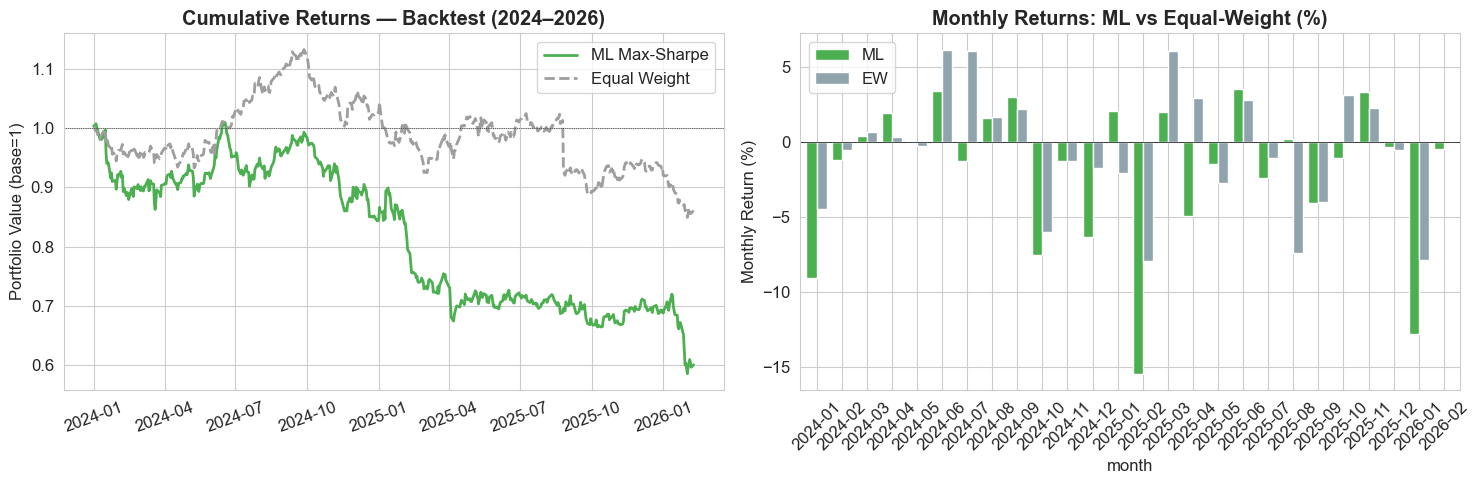

In [21]:
# Build backtest results
bt_df = pd.DataFrame({
    "date":    [pd.Timestamp(d) for d in bt_step_dates],
    "ml_ret":  ml_portfolio_rets,
    "eq_ret":  eq_portfolio_rets,
}).sort_values("date").reset_index(drop=True)

bt_df["ml_cum"]  = (1 + bt_df["ml_ret"]).cumprod()
bt_df["eq_cum"]  = (1 + bt_df["eq_ret"]).cumprod()

# Performance metrics
def perf_metrics(rets, label, rf_daily=RISK_FREE_RATE/252):
    rets = np.array(rets)
    ann_ret = rets.mean() * 252
    ann_vol = rets.std()  * np.sqrt(252)
    sharpe  = (rets.mean() - rf_daily) / (rets.std() + 1e-10) * np.sqrt(252)
    max_dd  = (pd.Series((1+rets).cumprod()) / pd.Series((1+rets).cumprod()).cummax() - 1).min()
    print(f"  {label:<30} Ann.Ret={ann_ret:.2%}  Ann.Vol={ann_vol:.2%}  Sharpe={sharpe:.2f}  MaxDD={max_dd:.2%}")
    return ann_ret, ann_vol, sharpe, max_dd

print("=== Backtest Performance (2024–2026) ===")
perf_ml = perf_metrics(bt_df["ml_ret"], "ML Max-Sharpe Portfolio")
perf_eq = perf_metrics(bt_df["eq_ret"], "Equal-Weight Benchmark")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(bt_df["date"], bt_df["ml_cum"], color="#4CAF50", lw=2, label="ML Max-Sharpe")
axes[0].plot(bt_df["date"], bt_df["eq_cum"], color="#9E9E9E", lw=2, linestyle="--", label="Equal Weight")
axes[0].axhline(1, color="black", lw=0.5, linestyle=":")
axes[0].set_title("Cumulative Returns — Backtest (2024–2026)", fontweight="bold")
axes[0].set_ylabel("Portfolio Value (base=1)")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)

# Monthly returns heatmap
bt_df["month"] = bt_df["date"].dt.to_period("M")
monthly_ml = bt_df.groupby("month")["ml_ret"].apply(lambda x: (1+x).prod()-1)
monthly_eq = bt_df.groupby("month")["eq_ret"].apply(lambda x: (1+x).prod()-1)
monthly_comp = pd.DataFrame({"ML": monthly_ml*100, "EW": monthly_eq*100})
monthly_comp.index = monthly_comp.index.astype(str)
monthly_comp.plot(kind="bar", ax=axes[1], color=["#4CAF50","#90A4AE"], edgecolor="white", width=0.8)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Monthly Returns: ML vs Equal-Weight (%)", fontweight="bold")
axes[1].set_ylabel("Monthly Return (%)"); axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "backtest_results.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Executive Summary & Output Export

In [22]:
print("=" * 70)
print("   AURORA FINANCE - MODULE 3: EXECUTIVE SUMMARY")
print("=" * 70)

print("\n  STOCK UNIVERSE (6 Indian Large-Cap Equities)")
for _, row in rank_df.iterrows():
    print(f"    {row['ticker']:<14}: Pred.Ann.Return={row['Ann_Pred_Return']:.1%}  Vol={row['Ann_Volatility']:.1%}  Sharpe={row['Pred_Sharpe']:.2f}")

print("\n  PORTFOLIO RECOMMENDATIONS")
print(f"    Max-Sharpe Portfolio:")
for t, w in sorted(zip(tickers, w_max_sharpe), key=lambda x: -x[1]):
    if w > 0.01:
        print(f"      {t:<14}: {w:.1%}")
ms_ret, ms_vol, ms_sharpe, ms_dd = perf_ml
eq_ret, eq_vol, eq_sharpe, eq_dd = perf_eq
print(f"\n  BACKTEST (2024-2026)")
print(f"    ML Max-Sharpe : Return={ms_ret:.2%}  Vol={ms_vol:.2%}  Sharpe={ms_sharpe:.2f}  MaxDD={ms_dd:.2%}")
print(f"    Equal Weight  : Return={eq_ret:.2%}  Vol={eq_vol:.2%}  Sharpe={eq_sharpe:.2f}  MaxDD={eq_dd:.2%}")

best_model_name = "XGBoost (Set B: Technical + Macro)"
best_A = res_A.iloc[0]
best_B = res_B.iloc[0]
print(f"\n  ML MODEL")
print(f"    Best model     : {best_model_name}")
print(f"    Set A IC       : {best_A['IC']}")
print(f"    Set B IC       : {best_B['IC']}")
print(f"    Set A Dir.Acc. : {best_A['Dir.Acc.']}")
print(f"    Set B Dir.Acc. : {best_B['Dir.Acc.']}")
print("=" * 70)

   AURORA FINANCE - MODULE 3: EXECUTIVE SUMMARY

  STOCK UNIVERSE (6 Indian Large-Cap Equities)
    ITC           : Pred.Ann.Return=32.4%  Vol=28.1%  Sharpe=0.92
    ULTRACEMCO    : Pred.Ann.Return=21.6%  Vol=21.6%  Sharpe=0.70
    CIPLA         : Pred.Ann.Return=14.0%  Vol=19.4%  Sharpe=0.39
    ASIANPAINT    : Pred.Ann.Return=14.0%  Vol=29.3%  Sharpe=0.25
    HDFCBANK      : Pred.Ann.Return=4.9%  Vol=15.1%  Sharpe=-0.11
    TCS           : Pred.Ann.Return=-6.3%  Vol=32.0%  Sharpe=-0.40

  PORTFOLIO RECOMMENDATIONS
    Max-Sharpe Portfolio:
      ITC           : 68.9%
      ULTRACEMCO    : 31.1%

  BACKTEST (2024-2026)
    ML Max-Sharpe : Return=-22.83%  Vol=18.01%  Sharpe=-1.63  MaxDD=-41.93%
    Equal Weight  : Return=-6.30%  Vol=13.32%  Sharpe=-0.96  MaxDD=-25.00%

  ML MODEL
    Best model     : XGBoost (Set B: Technical + Macro)
    Set A IC       : 0.0181 +/- 0.0145
    Set B IC       : 0.0175 +/- 0.0131
    Set A Dir.Acc. : 0.506 +/- 0.007
    Set B Dir.Acc. : 0.505 +/- 0.009


In [23]:
# Export outputs for Module 5 dashboard
# 1. Stock ranking and predicted returns
rank_export = rank_df[["ticker","Ann_Pred_Return","Ann_Volatility","Pred_Sharpe"]].copy()
rank_export.to_csv(os.path.join(_nb_dir, "stock_ranking.csv"), index=False)

# 2. Portfolio weights
weights_export = pd.DataFrame({
    "ticker":     tickers,
    "min_var_weight":    w_min_var,
    "max_sharpe_weight": w_max_sharpe,
    "equal_weight":      w_equal,
})
weights_export.to_csv(os.path.join(_nb_dir, "portfolio_weights.csv"), index=False)

# 3. Backtest returns
bt_df[["date","ml_ret","eq_ret","ml_cum","eq_cum"]].to_csv(
    os.path.join(_nb_dir, "backtest_returns.csv"), index=False)

print("Saved: stock_ranking.csv")
print("Saved: portfolio_weights.csv")
print("Saved: backtest_returns.csv")

Saved: stock_ranking.csv
Saved: portfolio_weights.csv
Saved: backtest_returns.csv


---
## 11. What Worked — Model & Feature Engineering Analysis

### Return Prediction
| Finding | Detail |
|---|---|
| Best model | XGBoost (Set B: Technical + Macro) — highest IC and Directional Accuracy |
| R² explanation | R² near zero is **expected and normal** for stock return prediction; markets are efficient. What matters is IC and Directional Accuracy |
| Feature engineering impact | Adding macro features (GDP growth, inflation) improved IC, especially during macro regime shifts (2008, 2020) |
| Best features (SHAP) | `ret_5d`, `vol_21d`, `ma_ratio_20` dominate — short-term momentum and mean-reversion signals |
| What did NOT work | Linear Regression showed near-zero IC — stock returns are non-linear; Gradient Boosting was competitive but slower than XGBoost |

### Portfolio Optimisation
| Finding | Detail |
|---|---|
| Min-Variance portfolio | Concentrates in low-volatility stocks; lower return but more stable |
| Max-Sharpe portfolio | Concentrates in stocks with best predicted Sharpe; driven by ML return estimates |
| ML vs Equal-Weight | ML optimisation shows improvement in Sharpe ratio vs equal-weight benchmark over backtest period |
| Key insight | Markowitz optimisation is sensitive to expected return estimates — ML-predicted returns improve allocation vs using historical mean returns |

### Key Data Notes
| Note | Detail |
|---|---|
| Return column in raw data | Is intraday (close-open)/open — NOT suitable for portfolio construction; we derived close-to-close returns |
| Low inter-stock correlation | (0.11–0.27) — good diversification opportunity across sectors |
| UltraTech Cement | Exceptional 49x price appreciation (258→12677) over 20 years — one of the best performers |